In [6]:
!pip install yfinance



  Using cached yfinance-1.2.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached multitasking-0.0.12.tar.gz (19 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl.metadata (13 kB)
Using cached yfinance-1.2.0-py2.py3-none-any.whl (130 kB)
Using cached curl_cffi-0.13.0-cp39-abi3-win_amd64.whl (1.6 MB)
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15618 sha256=fc6daa3934c2af6818ccc3fabbfde67fe3068885d801630b3b50962fb2e65eb4
  Stored in directory: c:\users\janar\appdata\local\pip\cache\wheels\1e\df\0f\e2bbb22d689b30c681feb5410ab64a2523437b34c8ecfc6476
Successfully built multitasking

   ---------------------------------------- 0/5 [peewee]
   ---------------------------------------- 0/5 [peewee]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----------------------- 2/5 [websockets]
   ---------------- ----

  DEPRECATION: Building 'multitasking' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'multitasking'. Discussion can be found at https://github.com/pypa/pip/issues/6334


[*********************100%***********************]  4 of 4 completed
C:\Users\janar\AppData\Local\Temp\ipykernel_13088\17722370.py:20: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change().dropna()


CSV files created successfully!


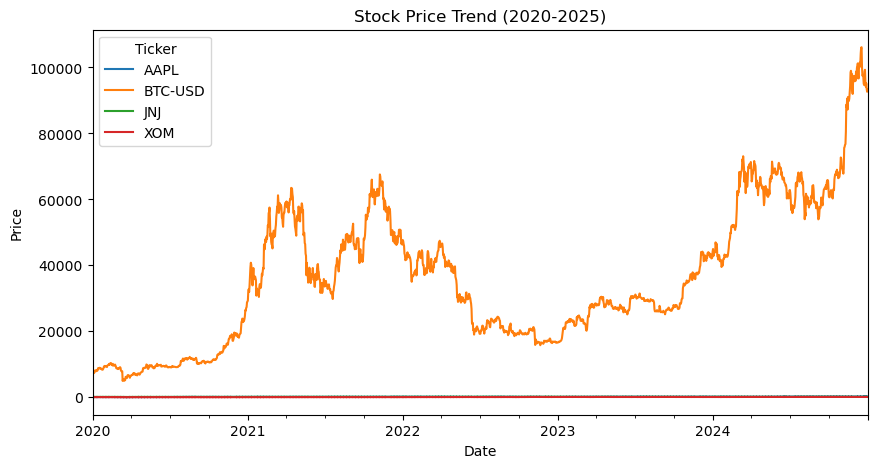

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np

# Step 1: Define portfolio stocks
tickers = ["AAPL", "JNJ", "XOM", "BTC-USD"]

# Step 2: Download stock price data
data = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-01-01",
    auto_adjust=True
)

# Step 3: Extract closing prices
prices = data["Close"]

# Step 4: Calculate daily returns
returns = prices.pct_change().dropna()

# Step 5: Define portfolio weights
weights = np.array([0.25, 0.25, 0.25, 0.25])

# Step 6: Calculate portfolio returns
portfolio_returns = returns.dot(weights)

# Step 7: Calculate portfolio growth
portfolio_value = (1 + portfolio_returns).cumprod()

# Step 8: Create portfolio dataframe
portfolio_df = pd.DataFrame({
    "Date": portfolio_returns.index,
    "Portfolio_Return": portfolio_returns,
    "Portfolio_Value": portfolio_value
})

# Step 9: Export CSV files for Tableau
prices.to_csv("stock_prices.csv")
returns.to_csv("stock_returns.csv")
portfolio_df.to_csv("portfolio_summary.csv", index=False)

print("CSV files created successfully!") 

import matplotlib.pyplot as plt

prices.plot(figsize=(10,5))
plt.title("Stock Price Trend (2020-2025)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

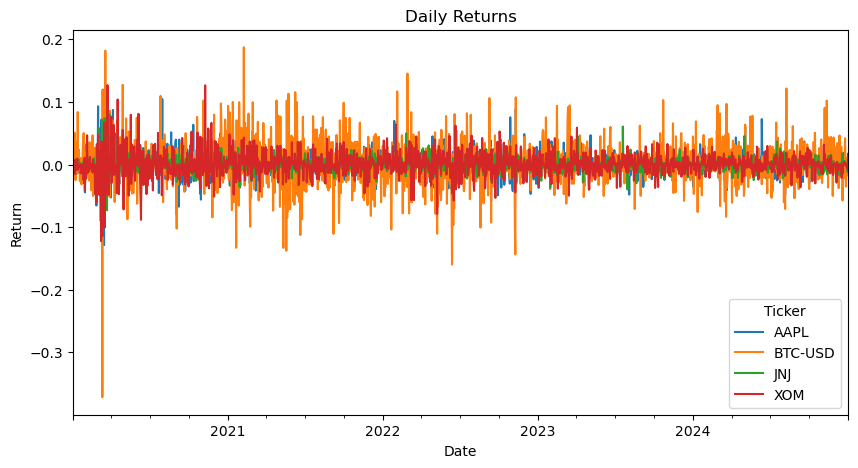

In [9]:
returns.plot(figsize=(10,5))
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

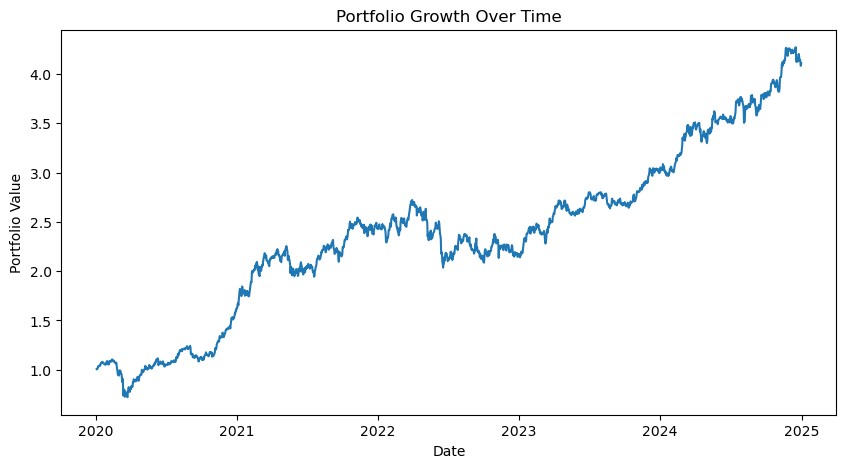

In [10]:
plt.figure(figsize=(10,5))
plt.plot(portfolio_df["Date"], portfolio_df["Portfolio_Value"])
plt.title("Portfolio Growth Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.show()

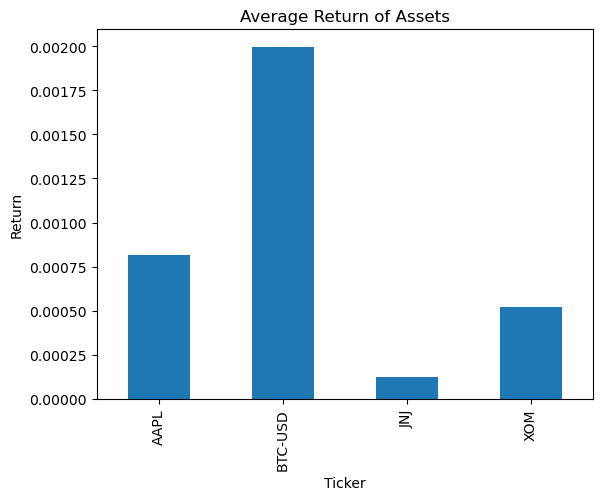

In [11]:
returns.mean().plot(kind="bar")
plt.title("Average Return of Assets")
plt.ylabel("Return")
plt.show()